So far we have been introduced to some supervised classification and regression models, Before moving furtehr we want to determine some descriptive concepts and then introduce some other supervised model and an accuracy test for classification models.

We have two types of methods: **Parametric** and **non-parametric**:

+ **Parametric**: Parametric method needs to **find** parameters from the input data and then use them to decide on new data points. So far every model/method we learned was parametric: **Linear Regression**, **Linear Classification** and  **Logistic Regression**.

> Even deep neural networks are parametric, despite having millions of parameters. 

+ **Non-parametric**: In these methods we do not assume a fixed form or number of parameters. They learn the shape of the function directly from the data, often storing the entire dataset or a large part of it. In these methods Training examples are **explicitly** used and the training phase is **not required**. (e.g., kNN)


> Non-parametric models get more complex as we add more data, and that's their strength.

In ML we have two types of learners: **Memory-based(Instance-based)** and **Model based** learners.

+ **Memory-based (Instance based)**: These types of learners don't build a general model, instead they **store** all or most of the training data, Use **similarity(distance)** between new input and stored instances to make predictions. These learners are often **lazy**: "**Train Later**" - most of the work happens at **prediction/test time**(e.g., kNN).

    + Memorize training $(x^{(i)}, y^{(i)}), ..., (x^{(n)}, x^{(n)})$
    + Given test $x$ predict: $\hat{y} = f(x; x^{(i)}, y^{(i)}, ...,x^{(n)}, x^{(n)})$
        + $f$ is typically expressed in terms of the similarity of the test samples $x$ to the training samples $x^{(1)}, ..., x^{(n)}$ (e.g., euclidean distance, cosine distance, manhattan distance, and ....)

> Instance-based learners has an aspect called `local generalization` which means: Each prediction depends only on nearby examples.

> Instance-based learners are non-parametric models and they operate **directly** on data instances.



+ **Model-Based Learning**: Model-based learners **abstract patterns** from data by learning parameters of a **model**, usually through opmiziation or fitting. They make assumptions about the form of the relationship, try to minimize a loss function during training, and do most of the work at training time which leads to fast prediction afterward.

So now let's get introduced to a non-parametric and instance based model:  k-NN.

## k-NN

k-NN's whole idea is to find the `k` nearrest neighbors to the smaple and based on them(memorized train data) predict the given sample.

What we are given in k-NN at first is the training data: $\{(x^{(i)}, y^{(i)}), ..., (x^{(n)}, x^{(n)})\}$

We can use k-NN both for classification and for regression problems.


#### k-NN classifier:

To classify a given input $x$ based on the memorized train data:

1. Find the $k$ nearest training samples to $x$
2. Out of these $k$ samples, identify the number of smaples $k_j$ belonging to class $C_j$ where $j = (1, ..., C)$
3. Assign $x$ to the class $C_{j^*}$ where $j^* = \argmax_{j} k_j$ 

> One of the benefits of using k-NN is we're able to obtain **non-linear** decision boundaries for our classification problems despite linear methods that we have so far learned(linear and logistic regression)

One of the downfall of k-NN is that it can be sensitive and prone to **outliers** or **noisy** data specially when we've got **small dataset** or our data is **low-dimensional** or if we use a **small** value of `k` (like `k = 1`) it will only be determined be the nearest neighbor and could be misleading in many test cases.

+ **Why outliers and noise are a problem?**

    + Noisy data can mislead neighbor voting:
        
        For example: A data point that should be class A is labeled as class B. If this noisy point happens to be close to our query point, it can mislead the prediction especially when: `k` is small, dataset is sparsed or classes are overlapping..

    + Outliers affect distance metrics:

        Outliers are data points that are **far away** from the normal distribution. Even though they're far, they can Be included as a neighbor when `k` is large, or skew the decision boundary.

Let's see some visual example of k-NN and what we have yet introduced of it:

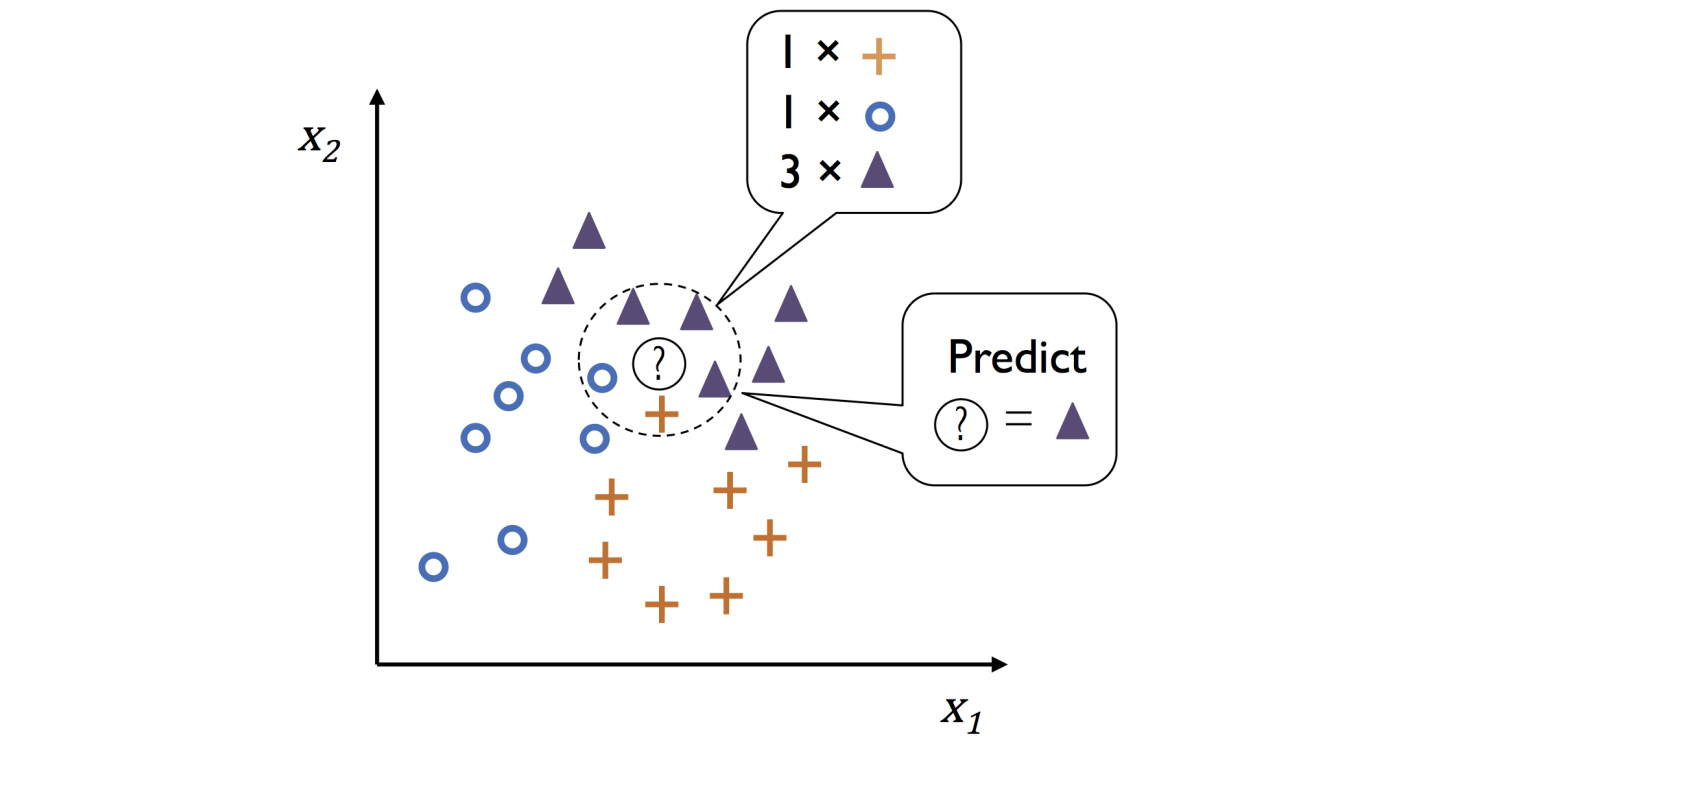
<center>Figure 1: Illustration of how k-NN classifier works (Raschka, 2020)</center>


**Tie**:

+ There is a situation in which we have equal number of each class in the `k` nearest neighbor of a smaple and we cannot decide the label of sample, we call this situation **tie**. 

**The imprtance of the value of `k` in prediction**:

+ **Too small k**:
    + Sensitive to noise
    + High variance
    + poor generalization
    
+ **Too large k**:
    + Dilutes local patterns, may ignore important structure
    + Biased toward majority class
    + May perform badly on imbalanced datasets.

> And later we're gonna explain how to choose the `k`. 

##### Voronoi tessellation:

A Voronoi tesselation divides a space into regions based on distance to a specific set of ponts.
Given a set of seed opints $P = \{p_1, p_2, ...., p_n\}$ in $R^d$, the voronoi cell $V_i$ of point $p_i$ is the set of all points in the space that are closer to $p_i$ than to any other $p_j$.
Each reigion $V_i$ is called a **Voronoi cell**.

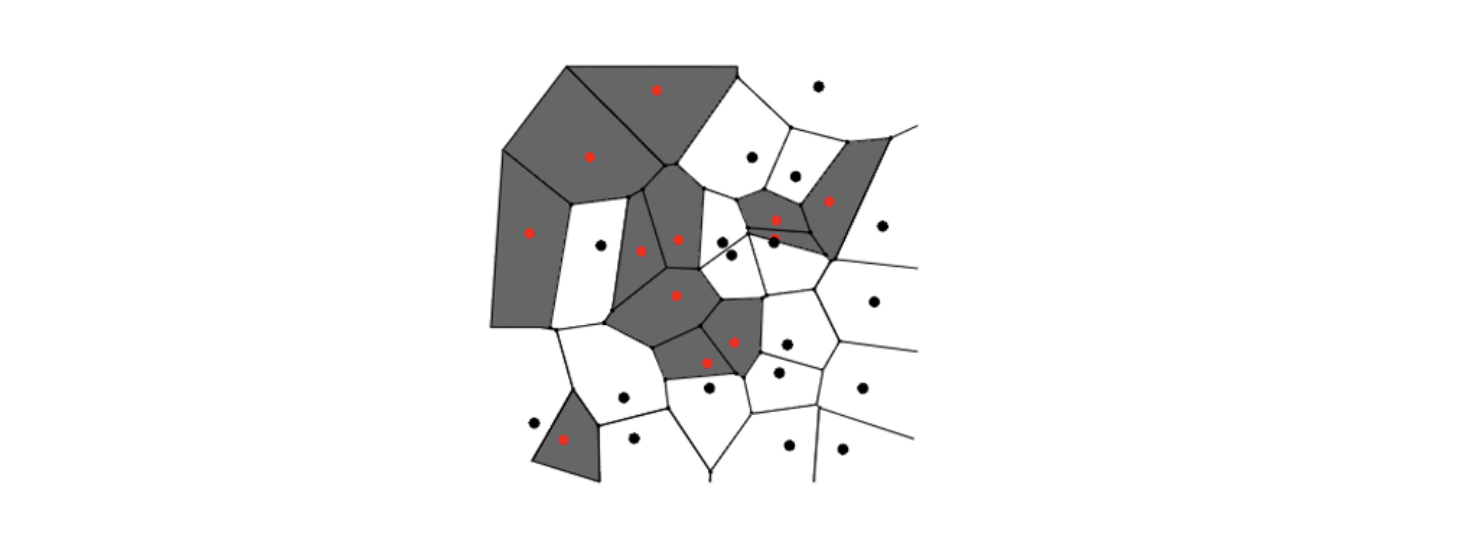
<center>Figure 2: Representation of voronoi tesselation and voronoi cells (Duda, Hurt and Strok's Book)</center>


The relation of it with k-NN:

In a **1-Nearest Neighbor** classification, a query point $x$ is assigned the **label of the nearest training ponint**. This is exactly what a Voronoi diagram encodes: each cell corresponds to the **area of influence** of a training point. Every Voronoi cell where **1-NN** would always predict the sample label. The **boundaries** between cells are places where the classifier is **indifferent** between two or more nearest neighbors.

We talked about that one of the k-NN classifier's benefits is that it is able to create non-linear decision boudaries and if you notice the above's explanation of Voronoi tessellation is setting a non-lineaer decision boundary for `k = 1` for each class and by somehow connecting the borders of same classes we will get the decision boudaries of our datasets.

As we saw the value of `k` has an effect on the shape of the decison boundary and the change in value of `k` can lead to change in the shape of the decision boudary.

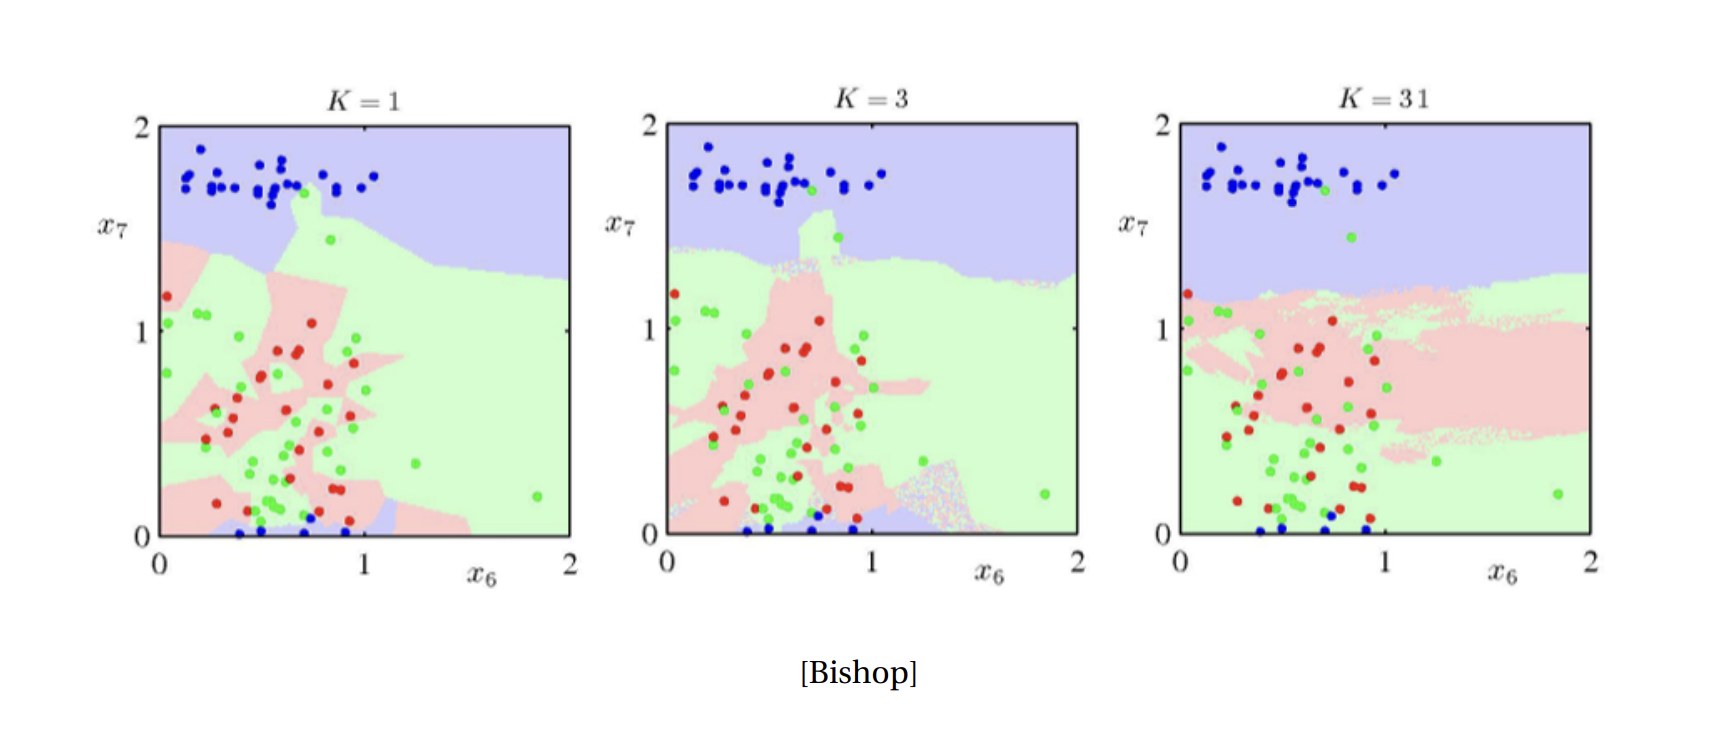
<center>Figure 3: Effect that value of k has on the shape of the decision boundary (Bishop)</center>


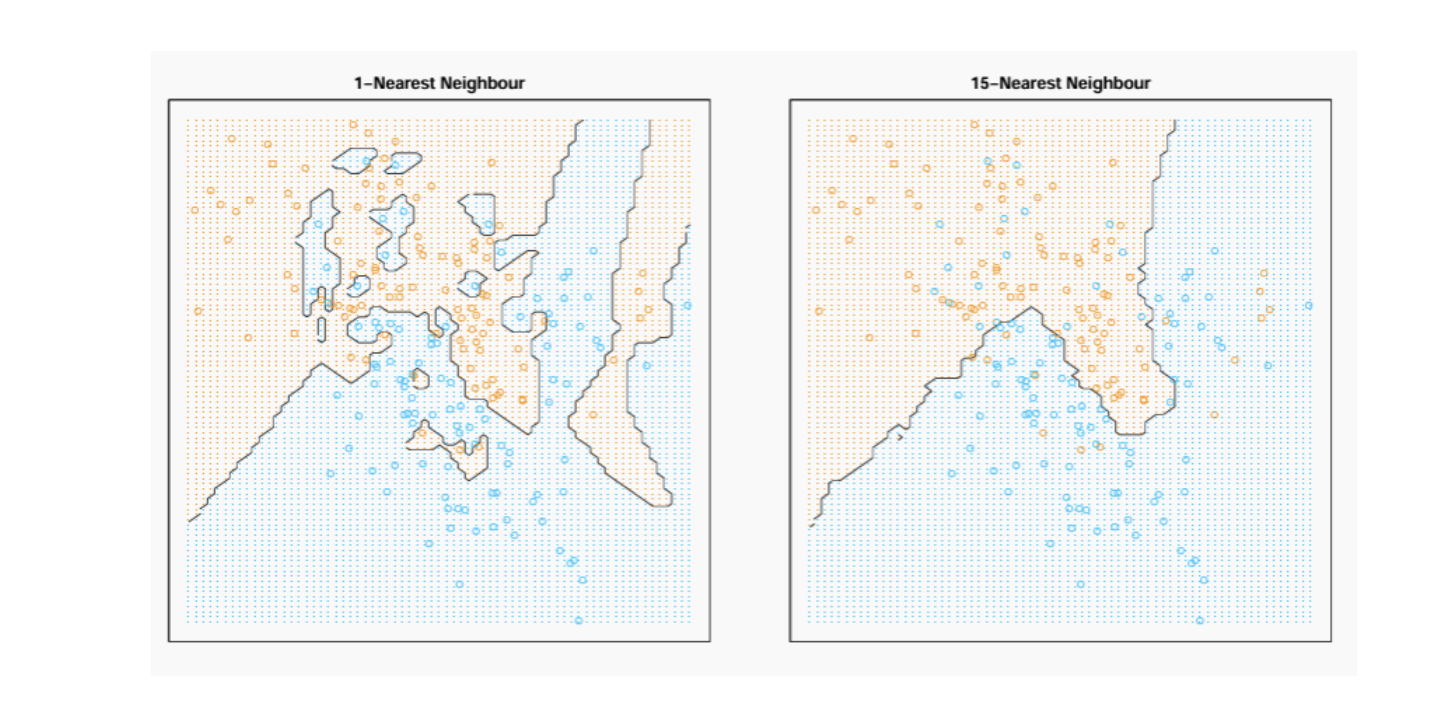
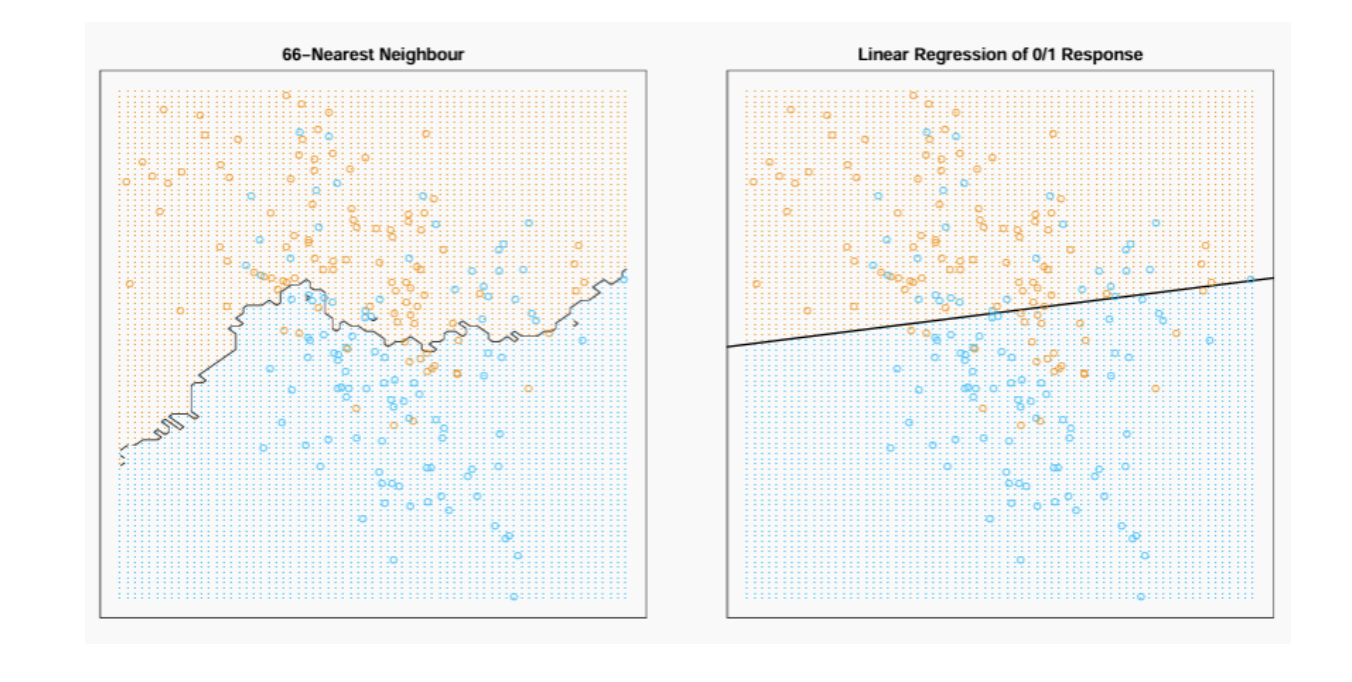
<center>Figure 4: Figures showing the change in decision boundaries due to value of k (ML course, Sharif University)</center>

Above figures is showing that as we further increase `k`, the model tends to be less complex. And from that we're gonna be able to conclude if we set `k` too big we will get into underfit problems as well and the model would not be able to predict the class very well.

Let's back up a bit, What are the main things to construct an instance-based learner:

+ Adistance metric
+ Number of nearest neighbors of the test data that we look at
+ A weighting function (optional, and for solving *tie* problems)
+ How to find the output based on neighbors?

##### Distance Metric:

A **distance metric** is a mathematical function that quantifies **how far apart two points are** in space (usually a features space).
In k-NN, the distance metric is used to **compare how similar or dissimilar two data points are**.

**How it works:**
1. We give the model a query point $x_{query}$
2. It computes the distance between $x_{query}$ and **every training point**
3. It selects the **k nearest neighbors** 
4. It makes a prediction based on these nearest neighbors.

##### Common distance metric in k-NN:

+ Euclidean distance
$$d(x, x') = \sqrt{(||x - x'||_2^2)} = \sqrt{(x_1 - x_1')^2 + ... + (x_d - x_d')^2}$$

> Euclidean distance is the most common metric which measures the *straight line* distance. Intuitive for real-world measurements (e.g. spatial data, would not prefer for datasamples with multiple features.)

+ For times we run to a tie or a feature or aspect is more important than the other we use:
    + Weighted Euclidean distance:
    $$d_w(x, x') = \sqrt{w_1(x_1 - x_1')^2 + ... + w_d(x_d - x_d')^2}$$

> Weights can also be a hyperparameter to influence on bias-varaince tradeoff.

> When we say $w_1(x_1 - x_1')$, $x_1$ and $x_1'$ can be two points of vector of features and when we put a weight vector we can mean that some features are more important than the others.

> It is mostly used when scale is handled

**Use when:**
+ Features are **numeric** and **continuous**
+ Features are on the same scale or have been normalized/standardized.
+ Our data is dense and low to medium dimensional


+ Minkowski distance:
    $$d(x, x') = (\sum_{i=1}^{n} |x_i - x_i'|^p)^{\frac{1}{p}}$$
    + For $p \geq 1$ is a diistance metric
    + For $ p = 2 $: Minkowski distance equals to Euclidean distance
    + Minkowski distance is the smae as $L^p$ norm of $(x - x')$

**Use when:**
+ When we want to experiment between L1 and L2
+ When we're doing model tunning(set p = 1, p = 2 or higher)

In paranthesis I just have to explain $L^p$ norm very quick.

+ $L^p$ norm from linear algebra:

    $$||x||_p = (|x_1|^p + ... + |x_n|^p)^{(1/p)}$$
    Some famous $L^p$ norms:
    + $||x||_1 = \sum_{i=1}^{n} |x_i|$
    + $||x||_2 = \sqrt{x_1^2 + ... + x_n^2}$
    + $||x||_{\infty} = max\{|x_1|, |x_2|, ..., |x_n|\}$

+ Cosine distance (angle):

    $$d(x, x') = 1 - \text{cosine similarity}(x, x')$$
    $$\text{cosine similarity}(x, x') = \frac{x.x'}{||x||_2||x'||_2} = \frac{\sum_{i = 1}^{d} x_ix'_i}{\sqrt{\sum_{i=1}^{d} x_i^2} \sqrt{\sum_{i=1}^{d} x_i'^2}}$$

    + In the equation above we have created two unit vector of our data samples and then multiplied them:
    $$\text{data sample x unit vector: } \frac{x}{||x||_2}, \text{dadtasample x' unit vector: } \frac{x'}{||x'||_2}$$


    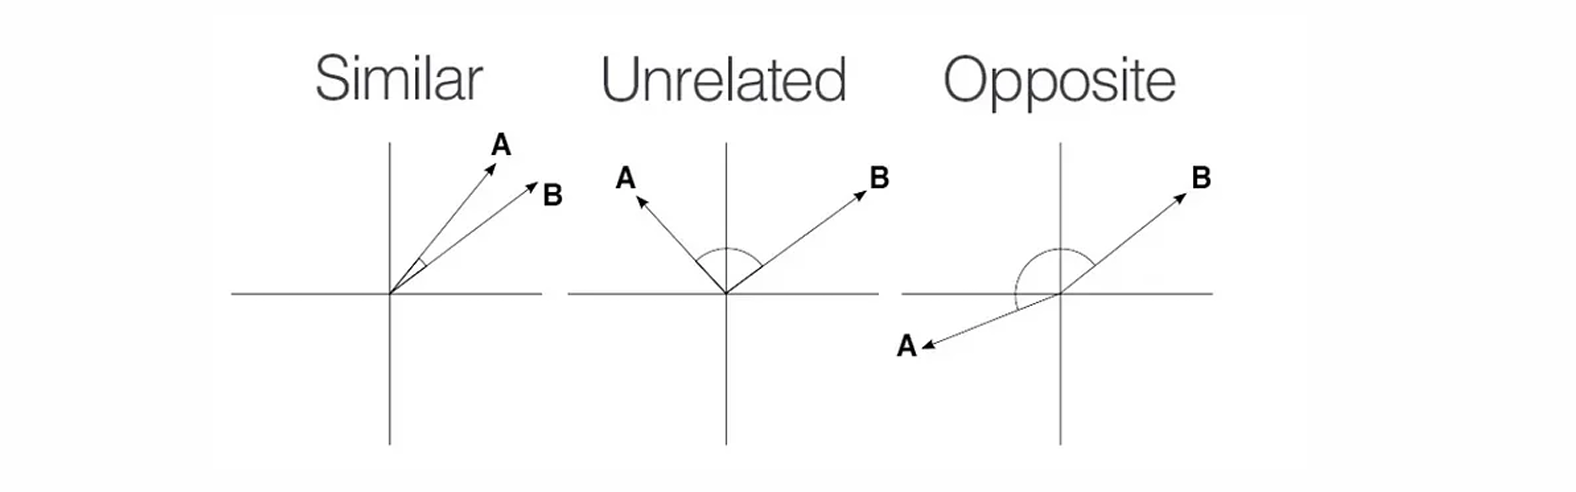
    <center>Figure 5: Example of angle difference for cosine similarity</center>


**Use when:**
+ We care more about dimension than magnitude
+ We're working with text, word embedding, or TF-IDF features
+ Features are high-dimensional and sparse


**Why distance metric matters in k-NN**:

+ It defines the decision boundary: Different metrics lead to different set of neighbors which means different predictions
+ A poor choice can hurt performance: If we use Euclidean distance with features **on different scales**, features with large values dominate the distace. So we often need to **normalize** or **standardize** data. 

#### kNN Regression:

It's the same as classification but with a difference that we take the maean of the k nearest neighbors values as the prediction.

Let $x'^{(1)}, ..., x'^{(k)}$ be the k nearest neighbors of $x$ and $y'^{(1)}, ..., y'^{(k)}$ be their labels
$$\hat{y} = \frac{1}{k} \sum_{j=1}^{k} y'^{(j)}$$

Some of it's problems:

+ Discontinuities in the estimated function
+ 1NN: noise-fitting problem (overfit)
+ kNN (k > 1) smoothes away noise, but there could be other issues (e.g., flats the ends)

> The value of `k` still is important here, if we set it too small it can result in overfit and if we set it too big it can result in underfit, so we have to use the validation method to find the best value of the hyperparameter `k`.

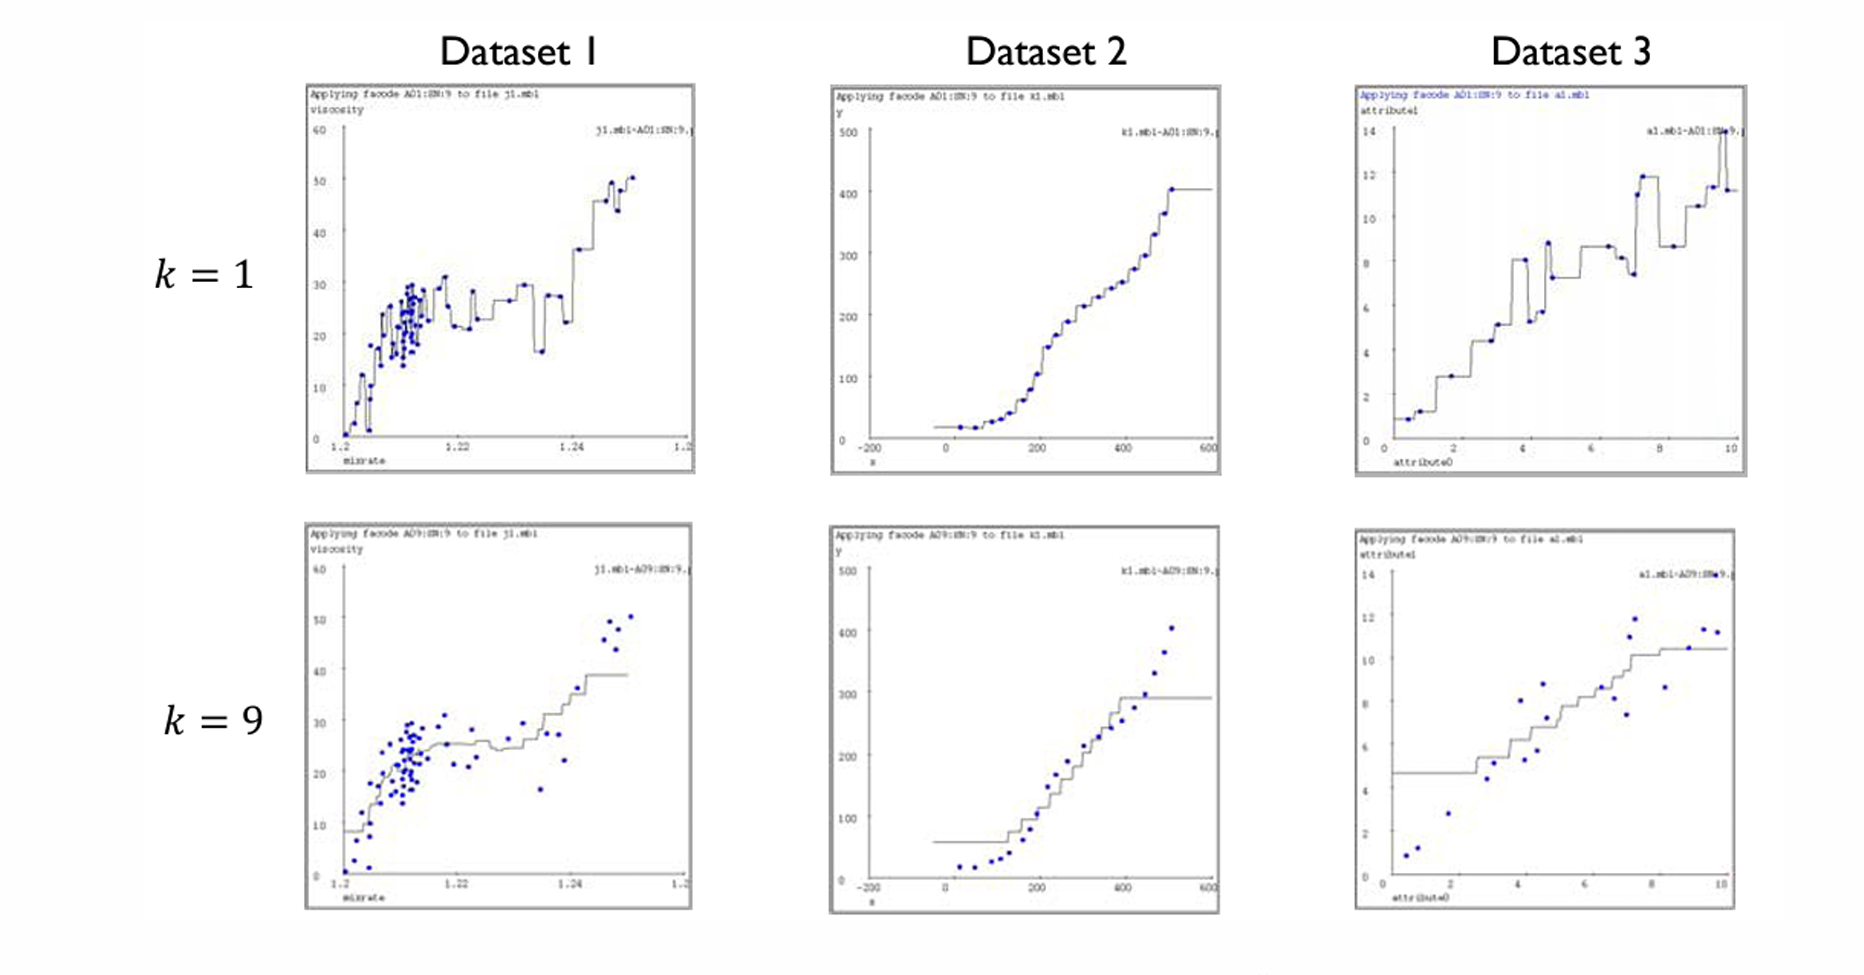
<center>Figure 6: kNN regression showing the effect of the value of k</center>

## Performance Metrics

Performace metrics play a crucial role in **evaluating** the **effectiveness** and accuracy of machine learning models. They provide insigghts into a model's predictive capabilities and help measures its performance across various tasks. 

##### Importance:
+ Performance metrics quantify the **quality** of predictions made by machine learning models.
+ They provide actionable insights for model evaluation, comparison, and improvement.

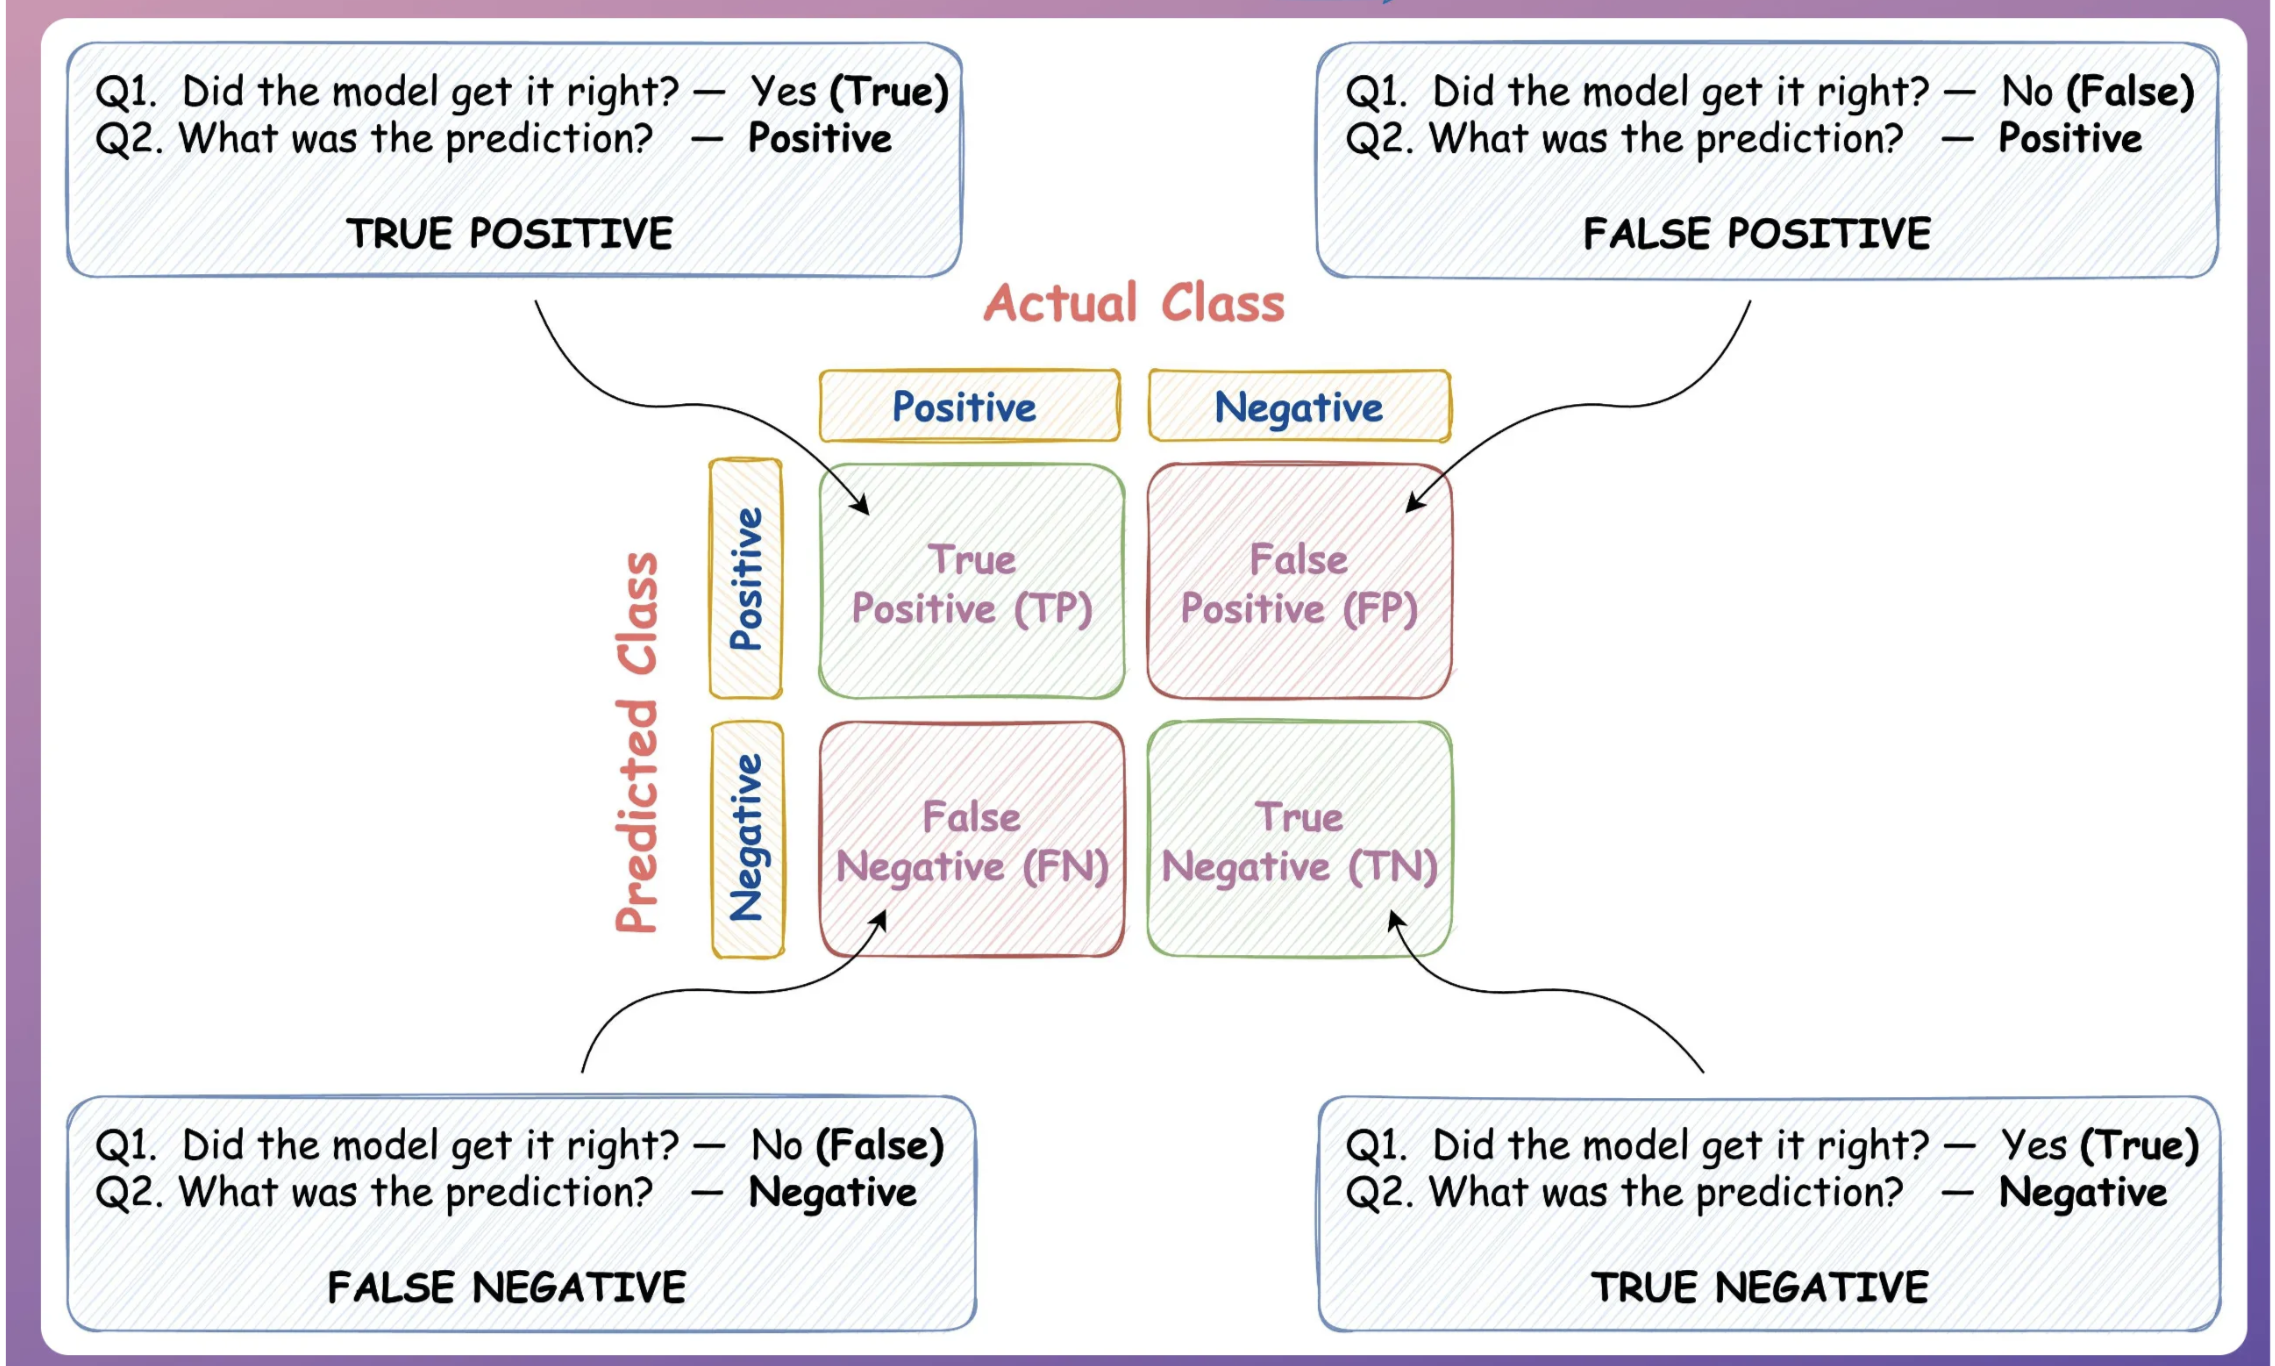
<center>Figure 6: Confusion Matrix</center>


> We will be using the definitions above in the figure of the confusion matrix to explain the formulas of performance metrics.

+ **Accuracy**:

    Is one of the simplest and most commonly used performance metrics. Accuracy measures the proportion of correct predictions (both true positive and true negative) among all predictions made by the model. It is defined as the ratio of correctly predicted instances to the toatal instances.

    $$\text{Accuracy} = \frac{\text{True Positive} + \text{True Negative}}{\text{Total Samples}}$$

> Accuracy alone can be misleading, especially with imbalance datasets.

Let's understand the above statement with an example:

If our dataset contains 1000 records out of which 900 belongs to class 1 and 100 belongs to 2, then if we told our model to predict class 1 everytime, our models efficiency is going to be 90%. This gives us high accuracy, but the model fails to detect any actual case of classification.
    
In highly imbalance datasets, the **majority class** is often underpresented. A model that always predicts the majority class can still have high accuracy, but poor real-world performance. We need better metrics to evaluate model performance.

+ **Recall(Sensitivity)**:

    Recall measures the proportion of true positive predictions among all actual positive instances in the dataset
    $$\text{sensitivity} = \frac{TP}{TP + FN}$$

    > "Out of the actual positives, how many did the model correctly identify?"

    + Whe prioritize this metric when the missing positives is dangerous.

+ **Specificity**:

    Specificity measures how well a classification model correctly identifies the negative class. It answers this question: 
    > Out of all the actual negatives, how many did the model correctly label as negative?

    $$\text{specificity} = \frac{TN}{TN + FP}$$

    + High specificity = few false positives
    + Useful in scenarios where false alarms are dangerous or expensive

+ **Precision**:

    Precision measures the proportion of the true positive predictions among all positive predictions made by the model
    $$\text{Precision} = \frac{TP}{TP + FP}$$
    > "Out of all predictions where the model said positive, how many were actually positive?"
    + Prioritize when false positives are costly

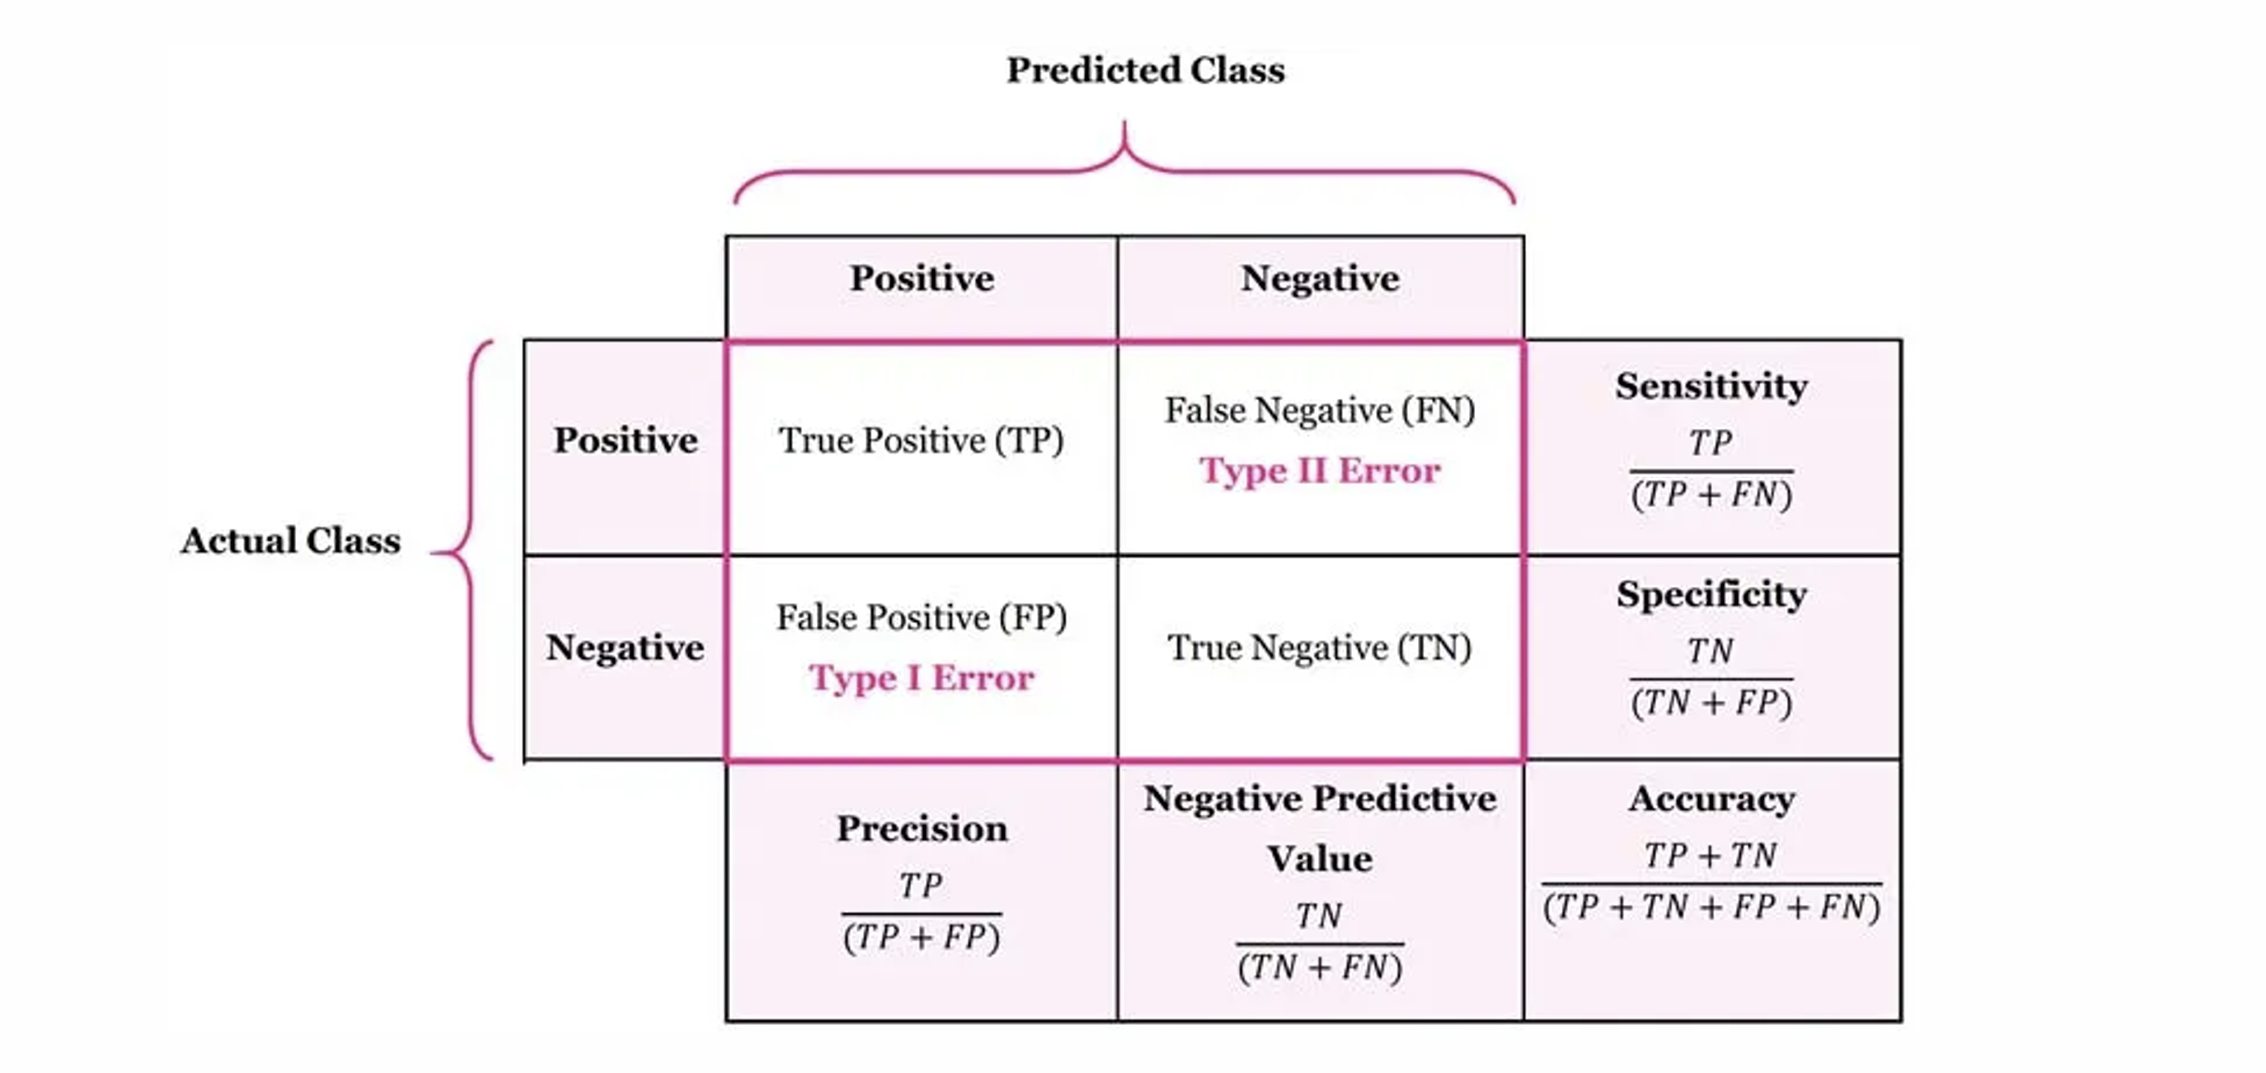
<center>Figure 7: visualization of peformance metrics with confusion matrix</center>

+ **F1 Score**:

    F1 score is also a performance metric that measures a model's accuracy. It combines the **precision** and **recall** of a model.
    F1 score is the **harmonic mean** of **precision** and **recall**. It combines both into a single number to give a better overall measure of a model's performance, especially when the data is imbalanced.

    $$\text{F1 Score} = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

    Use when:
    + When we're equally about precision and recall
    + When we have imbalanced classes
    + Missing a positive or raising false alarm both have costs.

    Why harmonic mean:
    + The harmonic mean punishes extreme values  more than the arithmetic mean.


So far knowing these performance metrics a question has been made for me:

+ What is the difference between loss function and performance metrics?

    To be straight forward, Loss functions are used during training to guide optimization, Performance metrics are used during **evaluation** to measure how good a model is.




**Let's see an example of the k-NN classifier**:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.cm as cm

In [ ]:
class KNNClassifier:
    def __init__(self, k=3, distance_func=None):
        self.k = k
        if distance_func is None:
            self.distance_func = self._euclidean_distance
        else:
            self.distance_func = distance_func
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum(x1 - x2) ** 2)
    
    def _manhattan_distance(self, x1, x2):
        return np.sum(np.abs(x1 - x2))
    
    def _minkowski_distance(self, x1, x2, p=3):
        return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)

SyntaxError: incomplete input (1143162282.py, line 9)

**References:**

[1] [Raschka, S. (2020). *Stat 451: Introduction to Machine Learning – Lecture Notes*. University of Wisconsin-Madison.](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/02-knn__notes.pdf)

[2] [Duda, Hurt, and Strok's Book](https://www.researchgate.net/publication/228058014_Pattern_Classification)

[3] [ML course in Sharif University-kNN slides](https://github.com/SharifiZarchi/Introduction_to_Machine_Learning/blob/main/Slides/Chapter_01_Supervised_Learning/04-kNN/04-kNN.pdf)

[4] [Cosine distance and cosine similarity](https://medium.com/@milana.shxanukova15/cosine-distance-and-cosine-similarity-a5da0e4d9ded)

[5] [Confusion Matrix](https://substack.com/home)